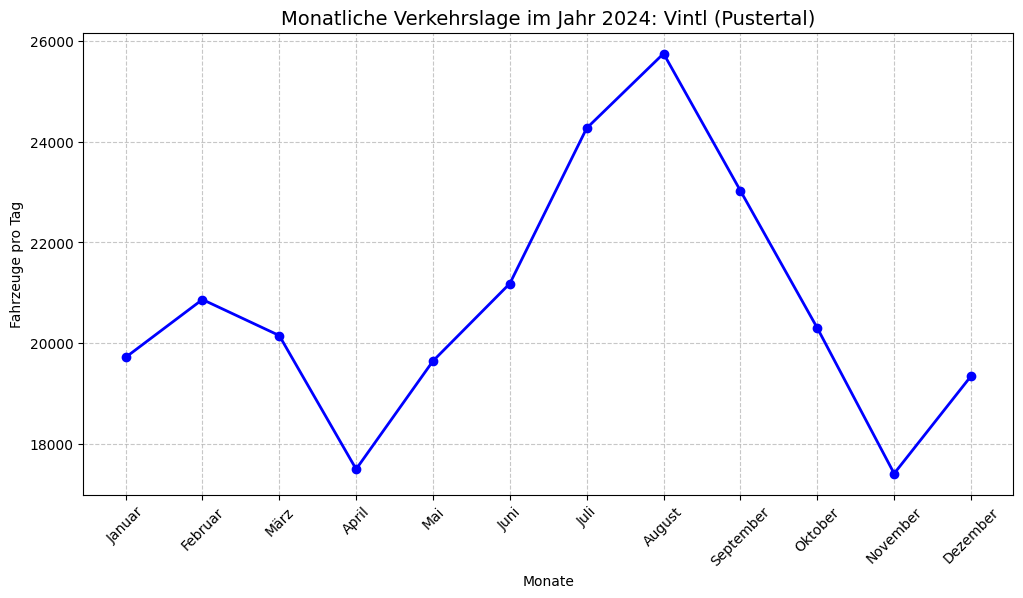

Tabellarische Übersicht:


,Monat,Durchschnittlicher Tagesverkehr nach Monat
0,Januar,19715.451613
1,Februar,20865.482759
2,März,20150.096774
3,April,17495.633333
4,Mai,19644.548387
5,Juni,21183.800000
6,Juli,24270.322581
7,August,25752.677419
8,September,23026.900000
9,Oktober,20300.064516


In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei einlesen
file_name = 'Daten_Vintl.xls'

try:
    # Einlesen mit xlrd
    df = pd.read_excel(file_name, engine='xlrd')

    # 1. FILTERN
    vintl_data = df[df['Zählstelle'].str.contains('Vintl', na=False, case=False)].copy()

    if vintl_data.empty:
        print("Keine Daten für 'Vintl' gefunden. Prüfe die Schreibweise in der Datei.")
    else:
        # 2. DATEN VORBEREITEN
        vintl_data = vintl_data.sort_values('Monat')

        # Liste der Monatsnamen für die Beschriftung
        monate_namen = ['Januar', 'Februar', 'März', 'April', 'Mai', 'Juni', 
                        'Juli', 'August', 'September', 'Oktober', 'November', 'Dezember']

        # 3. VISUALISIERUNG
        plt.figure(figsize=(12, 6))
        
        plt.plot(vintl_data['Monat'], 
                 vintl_data['Durchschnittlicher Tagesverkehr nach Monat'], 
                 marker='o', linestyle='-', color='blue', linewidth=2)

        plt.title('Monatliche Verkehrslage im Jahr 2024: Vintl (Pustertal)', fontsize=14)
        plt.xlabel('Monate')
        plt.ylabel('Fahrzeuge pro Tag')
        plt.grid(True, linestyle='--', alpha=0.7)

        # HIER DIE ÄNDERUNG: Zahlen durch Namen ersetzen
        # range(1, 13) entspricht den Zahlen 1-12 in deiner Datei
        plt.xticks(range(1, 13), monate_namen, rotation=45) 
        
        plt.show()
        
        # 4. DATAFRAME ANPASSEN (für die Anzeige unten)
        # Wir erstellen eine Kopie für die Anzeige, damit wir die Originalzahlen nicht verlieren
        display_df = vintl_data[['Monat', 'Durchschnittlicher Tagesverkehr nach Monat']].copy()
        
        # Hier werden die Zahlen in der Spalte 'Monat' durch die Namen ersetzt
        display_df['Monat'] = display_df['Monat'].map(monats_mapping)

        # Zeige die geänderte Tabelle an
        print("Tabellarische Übersicht:")
        display(display_df)


except Exception as e:
    print(f"Fehler: {e}")